# Wayfair E-Commerce Sales Analysis (2024–2025)

**Goal:** Clean two years of raw order-export data and turn it into a sales review that
shows how revenue changed, what drove it, and where the business should focus next year.

**Data sources:** `orders.csv`, `order_items.csv`, `products.csv`, `customers.csv` (all in `data/`)

This notebook is organized in the order of the assignment:
1. Load & clean the data (with every fix explained)
2. Define revenue
3. Monthly revenue trend & YoY comparison
4. Category breakdown & top products
5. Return/cancellation rate & AOV by category
6. Charts
7. One-page summary (findings + recommendations)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100


## 1. Load the data

In [2]:
orders = pd.read_csv("data/orders.csv", parse_dates=["order_date"])
items = pd.read_csv("data/order_items.csv")
products = pd.read_csv("data/products.csv")
customers = pd.read_csv("data/customers.csv", parse_dates=["signup_date"])

print("orders:", orders.shape)
print("order_items:", items.shape)
print("products:", products.shape)
print("customers:", customers.shape)


orders: (9245, 7)
order_items: (15608, 5)
products: (90, 5)
customers: (3600, 4)


## 2. Check each file for problems

Before touching the analysis, I audited every table for: exact duplicate rows, duplicate
keys, missing values, inconsistent category labels, and broken foreign keys between
tables. Each issue found is listed with the fix applied.


### 2a. `orders.csv` — exact duplicate rows

In [3]:
print("Rows before de-dup:", len(orders))
print("Fully duplicated rows:", orders.duplicated().sum())
print("Duplicated order_id values:", orders['order_id'].duplicated().sum())

# Inspect one example
example_id = orders[orders.duplicated(subset=['order_id'], keep=False)]['order_id'].iloc[0]
orders[orders['order_id'] == example_id]


Rows before de-dup: 9245
Fully duplicated rows: 38
Duplicated order_id values: 38


,order_id,customer_id,order_date,status,payment_method,discount_code,shipping_fee
47,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95
8560,100048,3320,2024-01-06 16:37:36,completed,credit_card,NaN,6.95


**Finding:** 38 orders appear twice, and in every case the second row is a byte-for-byte
copy of the first (same customer, timestamp, status, payment method, everything) — a
classic export/re-run duplicate, not two separate orders that happen to share an ID.

**Fix:** drop exact duplicate rows with `drop_duplicates()`. This leaves `order_id` unique,
which the assertion below confirms.


In [4]:
orders = orders.drop_duplicates()
assert orders['order_id'].is_unique
print("Rows after de-dup:", len(orders))


Rows after de-dup: 9207


### 2b. `orders.csv` — missing values and category-like columns

In [5]:
orders.isna().sum()


order_id             0
customer_id          0
order_date           0
status               0
payment_method       0
discount_code     7802
shipping_fee         0
dtype: int64

**Finding:** the only column with nulls is `discount_code` (most orders have none —
that's expected, not a data problem, since not every order used a promo code). No fix
needed; it's left as `NaN` meaning "no code used."

`status` and `payment_method` were checked for inconsistent labels (extra whitespace,
mixed case, typos) and came back clean:


In [6]:
print(orders['status'].value_counts())
print()
print(orders['payment_method'].value_counts())


status
completed    8456
returned      407
canceled      344
Name: count, dtype: int64

payment_method
credit_card    5310
paypal         1955
apple_pay      1413
gift_card       529
Name: count, dtype: int64


### 2c. `products.csv` — inconsistent category labels

In [7]:
print("Raw category values:")
print(sorted(products['category'].unique()))


Raw category values:
[' Bedding', ' Kitchen', ' Outdoor', 'BEDDING', 'Bath', 'Bedding', 'Decor', 'FURNITURE', 'Furniture', 'Furniture ', 'KITCHEN', 'Kitchen', 'Kitchen ', 'LIGHTING', 'Lighting', 'OUTDOOR', 'Outdoor', 'Storage', 'Storage ', 'bath', 'bedding', 'decor', 'furniture', 'kitchen']


**Finding:** the same 8 categories appear under many spellings — extra leading/trailing
spaces (`' Kitchen'`, `'Storage '`), inconsistent case (`'KITCHEN'`, `'kitchen'`,
`'Kitchen'`), all referring to one category. Left as-is, this would fragment every
category rollup into up to 4 copies of the same category.

**Fix:** strip whitespace and title-case every label.


In [8]:
products['category'] = products['category'].str.strip().str.title()
print("Cleaned category values:")
print(sorted(products['category'].unique()))
print()
print(products['category'].value_counts())


Cleaned category values:
['Bath', 'Bedding', 'Decor', 'Furniture', 'Kitchen', 'Lighting', 'Outdoor', 'Storage']

category
Kitchen      15
Bedding      12
Furniture    12
Decor        12
Outdoor      11
Bath         10
Lighting      9
Storage       9
Name: count, dtype: int64


Also checked `products.csv` for duplicate `product_id` values and null prices/costs —
none found, and `product_name` has no stray whitespace either.


In [9]:
print("Duplicate product_id:", products['product_id'].duplicated().sum())
print("Nulls per column:\n", products.isna().sum())


Duplicate product_id: 0
Nulls per column:
 product_id      0
product_name    0
category        0
list_price      0
unit_cost       0
dtype: int64


### 2d. `order_items.csv` — missing prices

In [10]:
print("Missing unit_price rows:", items['unit_price'].isna().sum())
print("Distinct products affected:", items.loc[items['unit_price'].isna(), 'product_id'].nunique())
items[items['unit_price'].isna()].head()


Missing unit_price rows: 199
Distinct products affected: 78


,order_id,product_id,quantity,unit_price,discount_amount
55,100033,1086,1,NaN,0.0
110,100062,1020,1,NaN,0.0
197,100116,1087,2,NaN,0.0
366,100210,1014,1,NaN,0.0
626,100361,1077,1,NaN,0.0


**Finding:** 199 line items (out of 15,608) are missing `unit_price`, spread across 78
different products — this looks like a scanning/export gap rather than a pricing issue
tied to specific products, since most products have both good and missing rows.

I checked whether `unit_price` reliably tracks the product's catalog price
(`products.list_price`) for the rows that *do* have it:


In [11]:
check = items.merge(products[['product_id', 'list_price']], on='product_id', how='left')
print("Correlation between unit_price and list_price:", check['unit_price'].corr(check['list_price']))


Correlation between unit_price and list_price: 0.9993840311138779


Correlation is effectively 1.0 — `unit_price` is just the catalog price captured at the
time of the order, with no meaningful drift or discounting baked in (discounting is
tracked separately in `discount_amount`, confirmed below).

**Fix:** fill missing `unit_price` with the matching product's `list_price`.


In [12]:
items = items.merge(products[['product_id', 'list_price']], on='product_id', how='left')
items['unit_price'] = items['unit_price'].fillna(items['list_price'])
items = items.drop(columns=['list_price'])
assert items['unit_price'].isna().sum() == 0
print("Missing unit_price after fix:", items['unit_price'].isna().sum())


Missing unit_price after fix: 0


### 2e. `order_items.csv` — duplicate rows and sanity checks

In [13]:
print("Exact duplicate item rows:", items.duplicated().sum())
print("Zero/negative quantity:", (items['quantity'] <= 0).sum())
print("Negative unit_price:", (items['unit_price'] < 0).sum())
print("Negative discount_amount:", (items['discount_amount'] < 0).sum())


Exact duplicate item rows: 0
Zero/negative quantity: 0
Negative unit_price: 0
Negative discount_amount: 0


**Finding:** no duplicate line items and no negative/zero quantities or prices — this
table is otherwise clean.

I also verified `discount_amount` is internally consistent with `orders.discount_code`
(e.g. `HOLIDAY20` should mean ~20% off the line):


In [14]:
check2 = items.merge(orders[['order_id', 'discount_code']], on='order_id', how='left')
check2['line_gross'] = check2['unit_price'] * check2['quantity']
check2['implied_pct'] = check2['discount_amount'] / check2['line_gross']
check2.groupby('discount_code')['implied_pct'].mean()


discount_code
HOLIDAY20    0.200169
SPRING15     0.150079
WELCOME10    0.100052
Name: implied_pct, dtype: float64

This confirms `discount_amount` = line gross × the code's percentage
(`WELCOME10`≈10%, `SPRING15`≈15%, `HOLIDAY20`≈20%), with no orphaned discounts (an
amount with no code, or a code with no amount). No fix needed here — it's just useful to
know the mechanics before defining revenue.


### 2f. Referential integrity across all four tables

In [15]:
print("order_items referencing an order_id not in orders:", (~items['order_id'].isin(orders['order_id'])).sum())
print("orders with zero line items:", (~orders['order_id'].isin(items['order_id'])).sum())
print("order_items referencing a product_id not in products:", (~items['product_id'].isin(products['product_id'])).sum())
print("orders referencing a customer_id not in customers:", (~orders['customer_id'].isin(customers['customer_id'])).sum())
print("Duplicate customer_id:", customers['customer_id'].duplicated().sum())
print("Invalid-looking state codes:", customers[~customers['state'].str.match(r'^[A-Z]{2}$')].shape[0])


order_items referencing an order_id not in orders: 0
orders with zero line items: 0
order_items referencing a product_id not in products: 0
orders referencing a customer_id not in customers: 0
Duplicate customer_id: 0
Invalid-looking state codes: 0


**Finding:** every foreign key lines up and `customers.csv` has no null values, duplicate IDs, or malformed state codes. No fixes needed.

## 3. Revenue definition

> **Revenue** = net merchandise revenue from orders that ended in a completed sale.
>
> - Only orders with `status == 'completed'` count. `canceled` orders never completed,
>   and `returned` orders were unwound after the fact — neither represents a sale that
>   stuck, so both are excluded from revenue.
> - For each line item: `net_revenue = (unit_price × quantity) − discount_amount`.
> - Order revenue = sum of its line items' net revenue.
> - `shipping_fee` is **excluded** — it's a pass-through logistics cost, not merchandise
>   revenue.

This definition is applied everywhere below.


In [16]:
items['line_revenue'] = items['unit_price'] * items['quantity'] - items['discount_amount']

order_revenue = items.groupby('order_id')['line_revenue'].sum().rename('order_revenue')
orders = orders.merge(order_revenue, on='order_id', how='left')

orders['year'] = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.to_period('M')

completed = orders[orders['status'] == 'completed'].copy()

total_2024 = completed.loc[completed['year'] == 2024, 'order_revenue'].sum()
total_2025 = completed.loc[completed['year'] == 2025, 'order_revenue'].sum()

print(f"2024 revenue: ${total_2024:,.2f}")
print(f"2025 revenue: ${total_2025:,.2f}")
print(f"YoY change: {(total_2025/total_2024 - 1) * 100:.1f}%")


2024 revenue: $850,786.45
2025 revenue: $1,030,488.63
YoY change: 21.1%


## 4. Monthly revenue trend & 2025 vs 2024

In [17]:
monthly = completed.groupby('month')['order_revenue'].sum().reset_index()
monthly['month_str'] = monthly['month'].astype(str)
monthly['year'] = monthly['month'].dt.year
monthly['month_num'] = monthly['month'].dt.month

pivot = monthly.pivot(index='month_num', columns='year', values='order_revenue')
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.round(0)


year,2024,2025
Jan,54390.0,73031.0
Feb,63275.0,70451.0
Mar,71769.0,78710.0
Apr,64769.0,79890.0
May,73653.0,83113.0
Jun,67205.0,92238.0
Jul,77269.0,83373.0
Aug,62684.0,91426.0
Sep,60054.0,75188.0
Oct,68388.0,82006.0


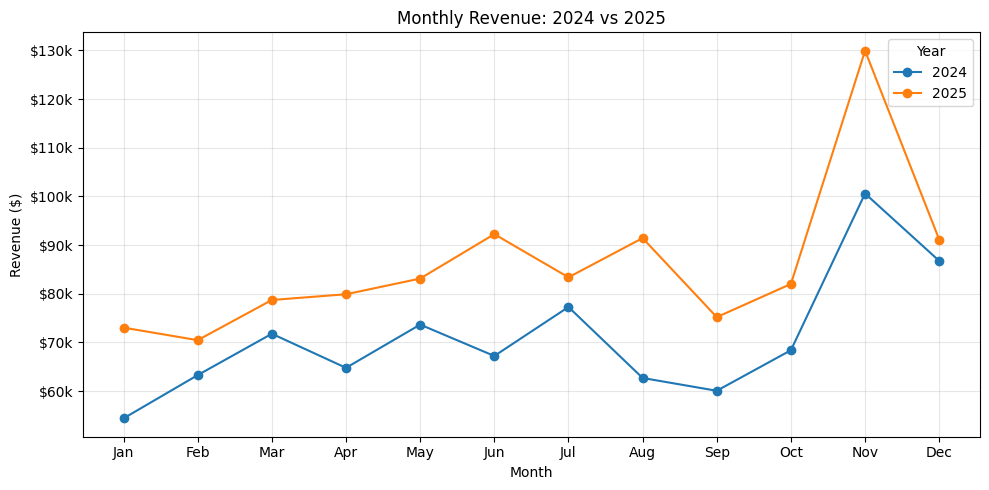

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
for yr in [2024, 2025]:
    sub = monthly[monthly['year'] == yr]
    ax.plot(sub['month_num'], sub['order_revenue'], marker='o', label=str(yr))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly Revenue: 2024 vs 2025')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(title='Year')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/01_monthly_revenue_trend.png', dpi=150)
plt.show()


**Reading the chart:**
- 2025 outsold 2024 in every single month — the YoY growth is broad-based, not driven by
  one or two outlier months.
- Both years show the same seasonal shape: a summer bump, a September dip, then a sharp
  **November spike** (Black Friday / holiday shopping) before Easing off in December.
- November is the single strongest month both years, and the November jump is proportionally
  larger in 2025 (~$130k) than in 2024 (~$100k) — holiday demand is growing faster than the
  baseline.


## 5. Revenue by category & top products

In [19]:
items_full = items.merge(orders[['order_id', 'status', 'year', 'month']], on='order_id', how='left')
items_full = items_full.merge(products[['product_id', 'product_name', 'category']], on='product_id', how='left')
completed_items = items_full[items_full['status'] == 'completed'].copy()

cat_rev = completed_items.groupby('category')['line_revenue'].sum().sort_values(ascending=False)
cat_rev


category
Furniture    322774.21
Kitchen      279719.21
Decor        277848.70
Bedding      266931.61
Outdoor      247612.23
Lighting     237737.13
Storage      139648.40
Bath         109003.59
Name: line_revenue, dtype: float64

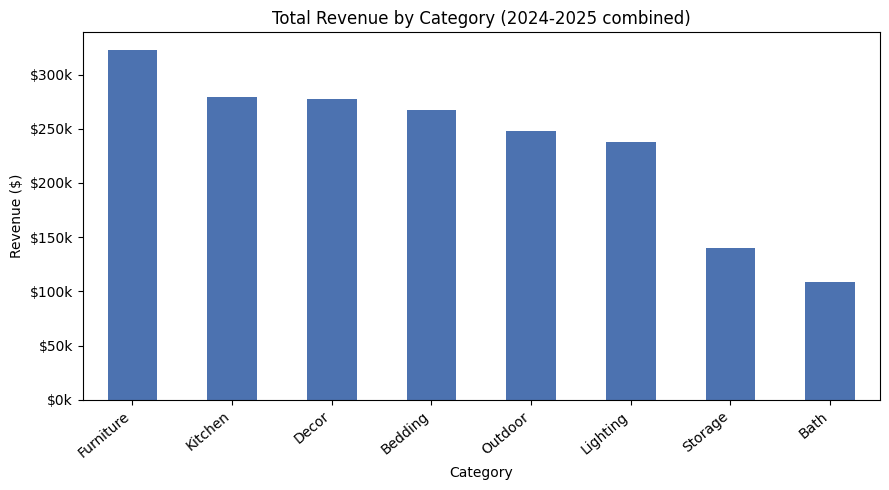

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
cat_rev.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Total Revenue by Category (2024-2025 combined)')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Category')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('charts/02_revenue_by_category.png', dpi=150)
plt.show()


In [21]:
top_products = (completed_items.groupby(['product_id', 'product_name'])['line_revenue']
                .sum().sort_values(ascending=False).head(10))
top_products


product_id  product_name             
1059        Cotton Patio Chair           67034.90
1042        Classic Dining Chair Pair    52017.94
1072        Coastal Picture Frame Set    44213.96
1018        Ceramic Quilt                41379.17
1044        Bamboo Nightstand            41339.23
1076        Modern Wreath                40995.15
1041        Nordic Side Table            40366.49
1054        Velvet String Lights         38803.92
1080        Classic Garland              38667.93
1040        Marble Bookshelf             38595.66
Name: line_revenue, dtype: float64

**Reading this:** Furniture is the top-grossing category despite having roughly the same
product count as the others — it's driven by a small number of high-ticket bestsellers
(the Cotton Patio Chair and Classic Dining Chair Pair alone bring in over $119k). Bath and
Storage are the smallest categories by revenue.


### Category mix over time

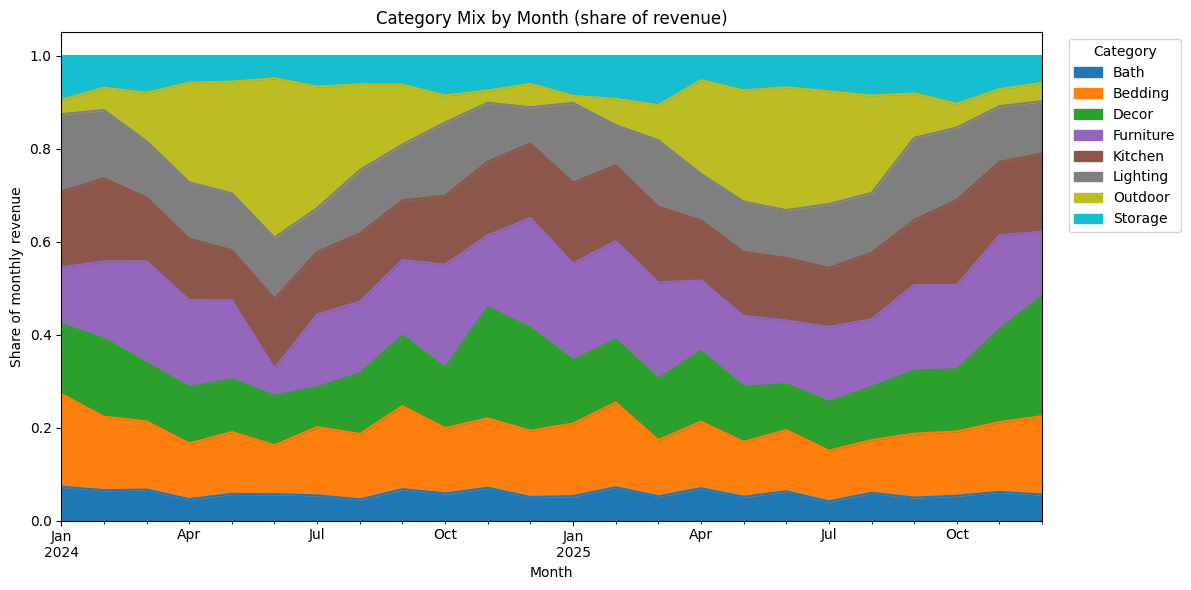

In [22]:
cat_month = completed_items.groupby(['month', 'category'])['line_revenue'].sum().unstack(fill_value=0)
cat_month_share = cat_month.div(cat_month.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
cat_month_share.plot(kind='area', stacked=True, ax=ax, cmap='tab10')
ax.set_title('Category Mix by Month (share of revenue)')
ax.set_ylabel('Share of monthly revenue')
ax.set_xlabel('Month')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('charts/03_category_mix_over_time.png', dpi=150)
plt.show()


**Reading this:** the category mix is seasonal, not static. **Outdoor** furniture/decor
swells to its largest share in spring/summer (peaking around May–June both years) and
nearly disappears in winter. **Decor** and **Furniture** do the opposite — they expand
sharply in November/December as gift and home-refresh purchases pick up. This means the
"average" category mix hides a real seasonal rotation the merchandising team should plan
inventory around.


## 6. Return/cancellation rate & average order value by category

In [23]:
# Assign each order to the category that contributed most of its revenue, so orders with
# items from more than one category are still counted once.
order_cat = items_full.groupby(['order_id', 'category'])['line_revenue'].sum().reset_index()
dominant_cat = (order_cat.sort_values('line_revenue', ascending=False)
                .drop_duplicates('order_id').set_index('order_id')['category'])
orders['dominant_category'] = orders['order_id'].map(dominant_cat)

cat_status = pd.crosstab(orders['dominant_category'], orders['status'])
cat_status['total'] = cat_status.sum(axis=1)
cat_status['return_rate'] = cat_status.get('returned', 0) / cat_status['total']
cat_status['cancel_rate'] = cat_status.get('canceled', 0) / cat_status['total']

aov_by_cat = (orders[orders['status'] == 'completed']
              .groupby('dominant_category')['order_revenue'].mean())

summary_cat = cat_status[['return_rate', 'cancel_rate']].copy()
summary_cat['aov'] = aov_by_cat
summary_cat = summary_cat.sort_values('aov', ascending=False)
summary_cat.style.format({'return_rate': '{:.1%}', 'cancel_rate': '{:.1%}', 'aov': '${:.2f}'})


status,return_rate,cancel_rate,aov
dominant_category,,,
Furniture,11.5%,3.0%,$506.78
Outdoor,4.0%,3.3%,$306.33
Lighting,3.6%,2.9%,$305.24
Bedding,3.7%,3.7%,$231.17
Decor,3.5%,3.7%,$162.12
Kitchen,3.6%,4.3%,$155.79
Storage,3.8%,3.6%,$133.83
Bath,3.7%,5.2%,$104.75


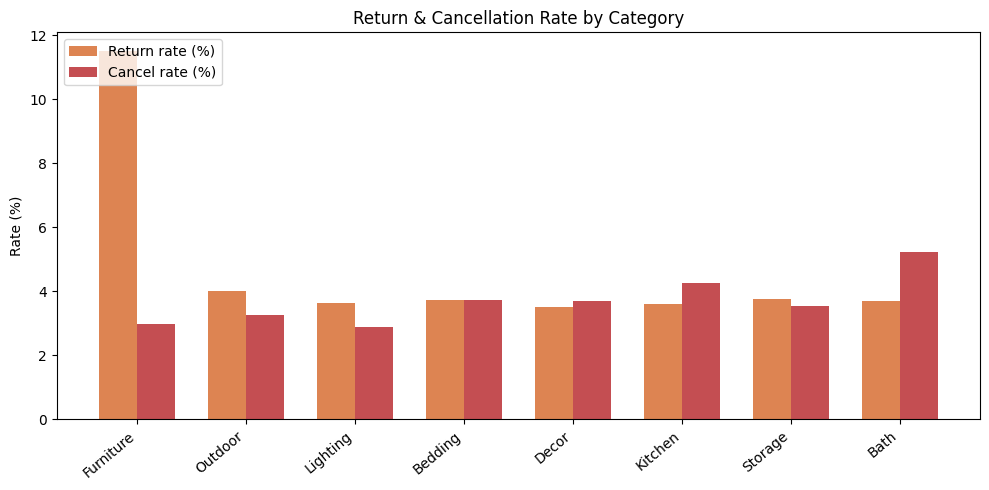

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary_cat))
width = 0.35
ax.bar(x - width/2, summary_cat['return_rate'] * 100, width, label='Return rate (%)', color='#DD8452')
ax.bar(x + width/2, summary_cat['cancel_rate'] * 100, width, label='Cancel rate (%)', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(summary_cat.index, rotation=40, ha='right')
ax.set_ylabel('Rate (%)')
ax.set_title('Return & Cancellation Rate by Category')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/04_return_cancel_rate_by_category.png', dpi=150)
plt.show()


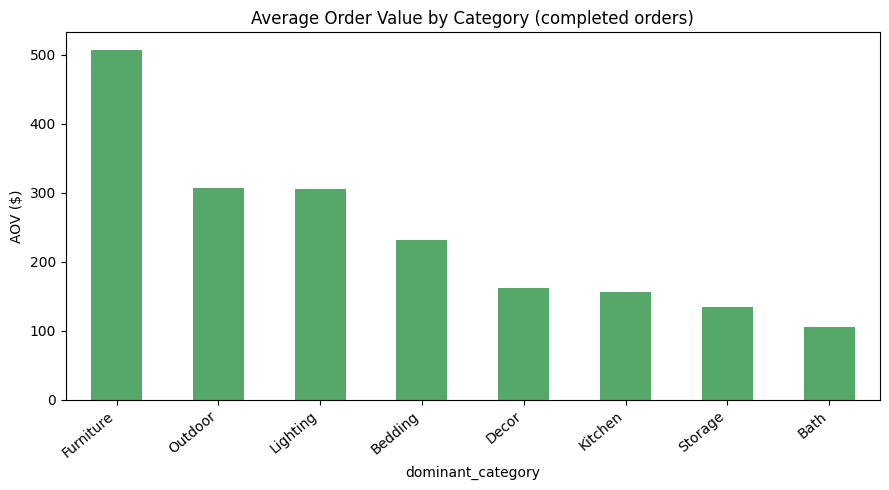

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
summary_cat['aov'].plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Average Order Value by Category (completed orders)')
ax.set_ylabel('AOV ($)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('charts/05_aov_by_category.png', dpi=150)
plt.show()


**Reading this:** Furniture has by far the highest AOV (~$507, more than 1.6x the next
category) **and** by far the highest return rate (~11.5%, roughly 3x every other
category). Every other category clusters tightly around a 3.5–5% return/cancel rate.
Bulky, high-value furniture is the standout risk: it drives outsized revenue per order but
also outsized reversals, which likely means outsized shipping/restocking cost per return
too.


## 7. Summary — Key Findings & Recommendations

### Key Findings

1. **Revenue grew 21% year over year** ($850.8k → $1,030.5k), and the growth was
   consistent — 2025 beat 2024 in every calendar month, not just at the holidays. Both
   years share the same seasonal shape: a mid-year lift, a September dip, and a sharp
   **November peak** that is the single biggest sales month by a wide margin.

2. **Furniture is the highest-revenue and highest-AOV category, but also by far the
   riskiest.** It generates the most total revenue and the highest average order value
   (~$507), driven by a handful of bestsellers (patio chairs, dining chair pairs), but its
   return rate (~11.5%) is roughly 3x every other category's (3.5–5%).

3. **Category mix rotates seasonally rather than staying constant.** Outdoor products
   peak in spring/summer and nearly vanish in winter; Decor and Furniture surge in
   November–December. A category's average yearly share understates how concentrated its
   real selling window is.

### Recommendations

1. **Investigate and address the Furniture return rate before scaling it further.**
   Given it is both the top revenue driver and the outlier on returns, even a modest
   reduction (e.g. via better size/fit information, sturdier packaging, or clearer
   assembly instructions) would protect a meaningful share of total revenue. Since returns
   on bulky furniture also carry higher reverse-logistics cost than a returned bath mat, this
   is likely the single highest-leverage fix available for next year's margin.

2. **Plan inventory and marketing spend around the seasonal category rotation, not the
   annual average.** Build up Outdoor inventory ahead of spring and Decor/Furniture
   inventory ahead of November, and shift acquisition spend toward those windows — the
   November spike shows the holiday period is already the biggest opportunity of the year
   and 2025's larger November suggests it is still growing.
